In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
#Cargar base df_model
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
modelo = pd.read_csv(file_name)
print(modelo.shape)
modelo.head()

Saving df_model.csv to df_model.csv
(29090, 36)


,customerID,n_buy,total_units_buy,avg_units_buy,total_value_buy,avg_value_buy,avg_profit_buy,profit_std_buy,n_assets_buy,n_categories_buy,...,avg_days_between_ops,n_transactions,buy_sell_ratio,net_units,net_value,risk_exposure,profitability_diff,riskLevel,investmentCapacity,customerType
0,00017496858921195E5A,80,146144.000,1826.800000,379542.059000,4744.275738,1.212326,1.485005,13,1,...,9.529412,124.0,1.777778,25117.000,30633.105000,728451.013000,0.145671,Aggressive,CAP_GT300K,Professional
1,00024864C985E72167A0,1,382.845,382.845000,4999.993985,4999.993985,0.029414,NaN,1,1,...,NaN,1.0,1.000000,382.845,4999.993985,4999.993985,NaN,Predicted_Conservative,Predicted_CAP_LT30K,Mass
2,0004718496C71D464F57,24,63176.000,2632.333333,356998.040000,14874.918333,-0.111018,0.807507,14,2,...,81.500000,36.0,1.846154,11040.000,283881.745000,430114.335000,-0.073759,Predicted_Conservative,Predicted_CAP_80K_300K,Mass
3,000676D07A4CF7526ECB,1,496.085,496.085000,4962.784731,4962.784731,0.002570,NaN,1,1,...,NaN,1.0,1.000000,496.085,4962.784731,4962.784731,NaN,Income,CAP_30K_80K,Mass
4,000900E880281981624D,1,7.000,7.000000,700.000000,700.000000,-0.160333,NaN,1,1,...,NaN,1.0,1.000000,7.000,700.000000,700.000000,NaN,Balanced,CAP_LT30K,Mass


Filtro para clientes activos segun su ultima operacion en la plataforma


In [ ]:
modelo = modelo[modelo['recency_days'] <= 365].copy()
print(f"Clientes para perfilar: {len(modelo):,}")

Clientes para perfilar: 12,613


In [ ]:
# 1. Crear variables indicadoras
modelo['es_vendedor'] = (modelo['n_sell'] > 0).astype(int)
modelo['vendedor_unico'] = (modelo['n_sell'] == 1).astype(int)
modelo['comprador_unico'] = (modelo['n_buy'] == 1).astype(int)

In [ ]:
# Lista de variables
todas_las_variables = [
    'buy_sell_ratio',
    'asset_diversification',
    'recency_days',
    'risk_exposure',
    'activity_days',
    'avg_profit_buy',
    'n_buy',
    'n_sell',
    'profit_std_buy',
    'n_categories_buy',
    'n_categories_sell',
    'category_diversification',
    'avg_days_between_ops',
    "investmentCapacity",
   "customerType",
   "es_vendedor",
   "vendedor_unico",
   "comprador_unico"
]

# Filtrar la base de datos
df_filtrado = modelo[todas_las_variables].copy()


Investigar nulos en profit_std_buy


In [ ]:
# Crear máscara
mask_nulos_std = df_filtrado['profit_std_buy'].isnull()

# Verificar cuantos nulos hay
n_nulos = mask_nulos_std.sum()
print(f"Valores nulos en profit_std_buy: {n_nulos}")

# Analizar los valores de n_buy para los registros nulos
distribucion_n_buy_nulos = df_filtrado.loc[mask_nulos_std, 'n_buy'].value_counts().sort_index()
print("\nDistribución de n_buy entre los nulos de profit_std_buy:")
print(distribucion_n_buy_nulos)

# Porcentaje de nulos que tienen exactamente n_buy == 1
porc_una_compra = (df_filtrado.loc[mask_nulos_std, 'n_buy'] == 1).mean()
print(f"\nPorcentaje de nulos con n_buy == 1: {porc_una_compra:.2%}")

# Ver si hay clientes con n_buy == 1 que NO tengan nulo
clientes_una_compra = (df_filtrado['n_buy'] == 1)
nulos_con_una_compra = df_filtrado.loc[clientes_una_compra, 'profit_std_buy'].isnull().mean()
print(f"Porcentaje de clientes con n_buy == 1 que tienen profit_std_buy nulo: {nulos_con_una_compra:.2%}")

# Si hay clientes con n_buy > 1  investigar
nulos_otras_compras = df_filtrado[mask_nulos_std & (df_filtrado['n_buy'] > 1)]
print(f"\nClientes con profit_std_buy nulo pero n_buy > 1: {len(nulos_otras_compras)}")
if len(nulos_otras_compras) > 0:
    print("Ejemplo de los primeros casos:")
    print(nulos_otras_compras[['n_buy', 'n_sell', 'asset_diversification']].head())

Valores nulos en profit_std_buy: 4306

Distribución de n_buy entre los nulos de profit_std_buy:
n_buy
1    4306
Name: count, dtype: int64

Porcentaje de nulos con n_buy == 1: 100.00%
Porcentaje de clientes con n_buy == 1 que tienen profit_std_buy nulo: 100.00%

Clientes con profit_std_buy nulo pero n_buy > 1: 0


Investigar nulos en avg_days_between_ops

In [ ]:
# Crear máscara de nulos en avg_days_between_ops
mask_nulos_avg = df_filtrado['avg_days_between_ops'].isnull()
print(f"Valores nulos en avg_days_between_ops: {mask_nulos_avg.sum()}")

# Calcular total de operaciones
total_ops = df_filtrado['n_buy'] + df_filtrado['n_sell']

# Distribución de total_ops para los nulos
distribucion_total_ops_nulos = total_ops[mask_nulos_avg].value_counts().sort_index()
print("\nDistribución de total de operaciones entre los nulos de avg_days_between_ops:")
print(distribucion_total_ops_nulos)

# Porcentaje de nulos con exactamente 1 operación total
porc_una_op = (total_ops[mask_nulos_avg] == 1).mean()
print(f"\nPorcentaje de nulos con exactamente 1 operación total: {porc_una_op:.2%}")

# Ver si hay clientes con 1 operación que NO tengan nulo
clientes_una_op = (total_ops == 1)
nulos_con_una_op = df_filtrado.loc[clientes_una_op, 'avg_days_between_ops'].isnull().mean()
print(f"Porcentaje de clientes con 1 op. que tienen avg_days_between_ops nulo: {nulos_con_una_op:.2%}")

# Si hay clientes con más de 1 operación y nulo, revisarlos
nulos_varias_ops = df_filtrado[mask_nulos_avg & (total_ops > 1)]
print(f"\nClientes con avg_days_between_ops nulo pero más de 1 operación total: {len(nulos_varias_ops)}")
if len(nulos_varias_ops) > 0:
    print("Posibles causas: operaciones en el mismo día (diferencia=0) o error de cálculo.")
    print(nulos_varias_ops[['n_buy', 'n_sell', 'activity_days']].head())

Valores nulos en avg_days_between_ops: 1104

Distribución de total de operaciones entre los nulos de avg_days_between_ops:
1.0    951
2.0    106
3.0     32
4.0     12
5.0      3
Name: count, dtype: int64

Porcentaje de nulos con exactamente 1 operación total: 86.14%
Porcentaje de clientes con 1 op. que tienen avg_days_between_ops nulo: 100.00%

Clientes con avg_days_between_ops nulo pero más de 1 operación total: 153
Posibles causas: operaciones en el mismo día (diferencia=0) o error de cálculo.
      n_buy  n_sell  activity_days
284       2     0.0              0
394       2     0.0              0
654       2     0.0              0
1243      3     0.0              0
1856      2     0.0              0


In [ ]:
# Crear la máscara de casos "anómalos"
mask_anomalos = df_filtrado['avg_days_between_ops'].isnull() & (df_filtrado['n_buy'] + df_filtrado['n_sell'] > 1)
anomalos = df_filtrado[mask_anomalos]

print(f"Clientes con >1 operación y avg_days_between_ops nulo: {len(anomalos)}")

# Ver la distribución de activity_days para estos clientes
print("\nDistribución de activity_days en los anómalos:")
print(anomalos['activity_days'].describe())
print("\nFrecuencia de activity_days == 0:")
print((anomalos['activity_days'] == 0).value_counts())

# Ver algunos ejemplos
print("\nPrimeros 10 casos anómalos:")
display(anomalos[['n_buy', 'n_sell', 'activity_days', 'recency_days']].head(10))

Clientes con >1 operación y avg_days_between_ops nulo: 153

Distribución de activity_days en los anómalos:
count    153.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: activity_days, dtype: float64

Frecuencia de activity_days == 0:
activity_days
True    153
Name: count, dtype: int64

Primeros 10 casos anómalos:


,n_buy,n_sell,activity_days,recency_days
284,2,0.0,0,307
394,2,0.0,0,84
654,2,0.0,0,296
1243,3,0.0,0,334
1856,2,0.0,0,293
2130,2,0.0,0,13
2461,2,0.0,0,187
3106,2,0.0,0,99
3193,4,0.0,0,293
3270,3,0.0,0,259


Imputacion en promedio de operaciones

In [ ]:
# Imputar 0 a los clientes de múltiples operaciones en mismo día
mask_misma_fecha = (df_filtrado['avg_days_between_ops'].isnull() &
                    (df_filtrado['n_buy'] + df_filtrado['n_sell'] > 1))
df_filtrado.loc[mask_misma_fecha, 'avg_days_between_ops'] = 0

Descriptivos variables numericas

In [ ]:
# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Lista de variables numéricas a analizar
vars_numericas = [
    'buy_sell_ratio', 'asset_diversification', 'recency_days',
    'risk_exposure', 'activity_days', 'avg_profit_buy',
    'n_buy', 'n_sell', 'profit_std_buy', 'n_categories_buy',
    'n_categories_sell', 'category_diversification'
]

# Estadísticos descriptivos
desc = df_filtrado[vars_numericas].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print("Estadísticos descriptivos:\n")
print(desc.round(2))

Estadísticos descriptivos:

       buy_sell_ratio  asset_diversification  recency_days  risk_exposure  \
count        12613.00               12613.00      12613.00       12613.00   
mean             1.61                   4.64        170.25      195358.19   
std              2.49                   6.94        111.63     1434679.68   
min              0.02                   1.00          0.00           0.15   
1%               0.20                   1.00          0.00           6.50   
5%               0.40                   1.00          6.00          55.19   
25%              0.50                   1.00         68.00        2122.50   
50%              1.00                   2.00        163.00       10188.00   
75%              1.83                   5.00        279.00       52750.14   
95%              5.00                  17.00        335.00      555355.40   
99%             10.00                  34.00        359.00     2727296.91   
max             74.00                 124.00    

Distribuciones de variables con mayor asimetria

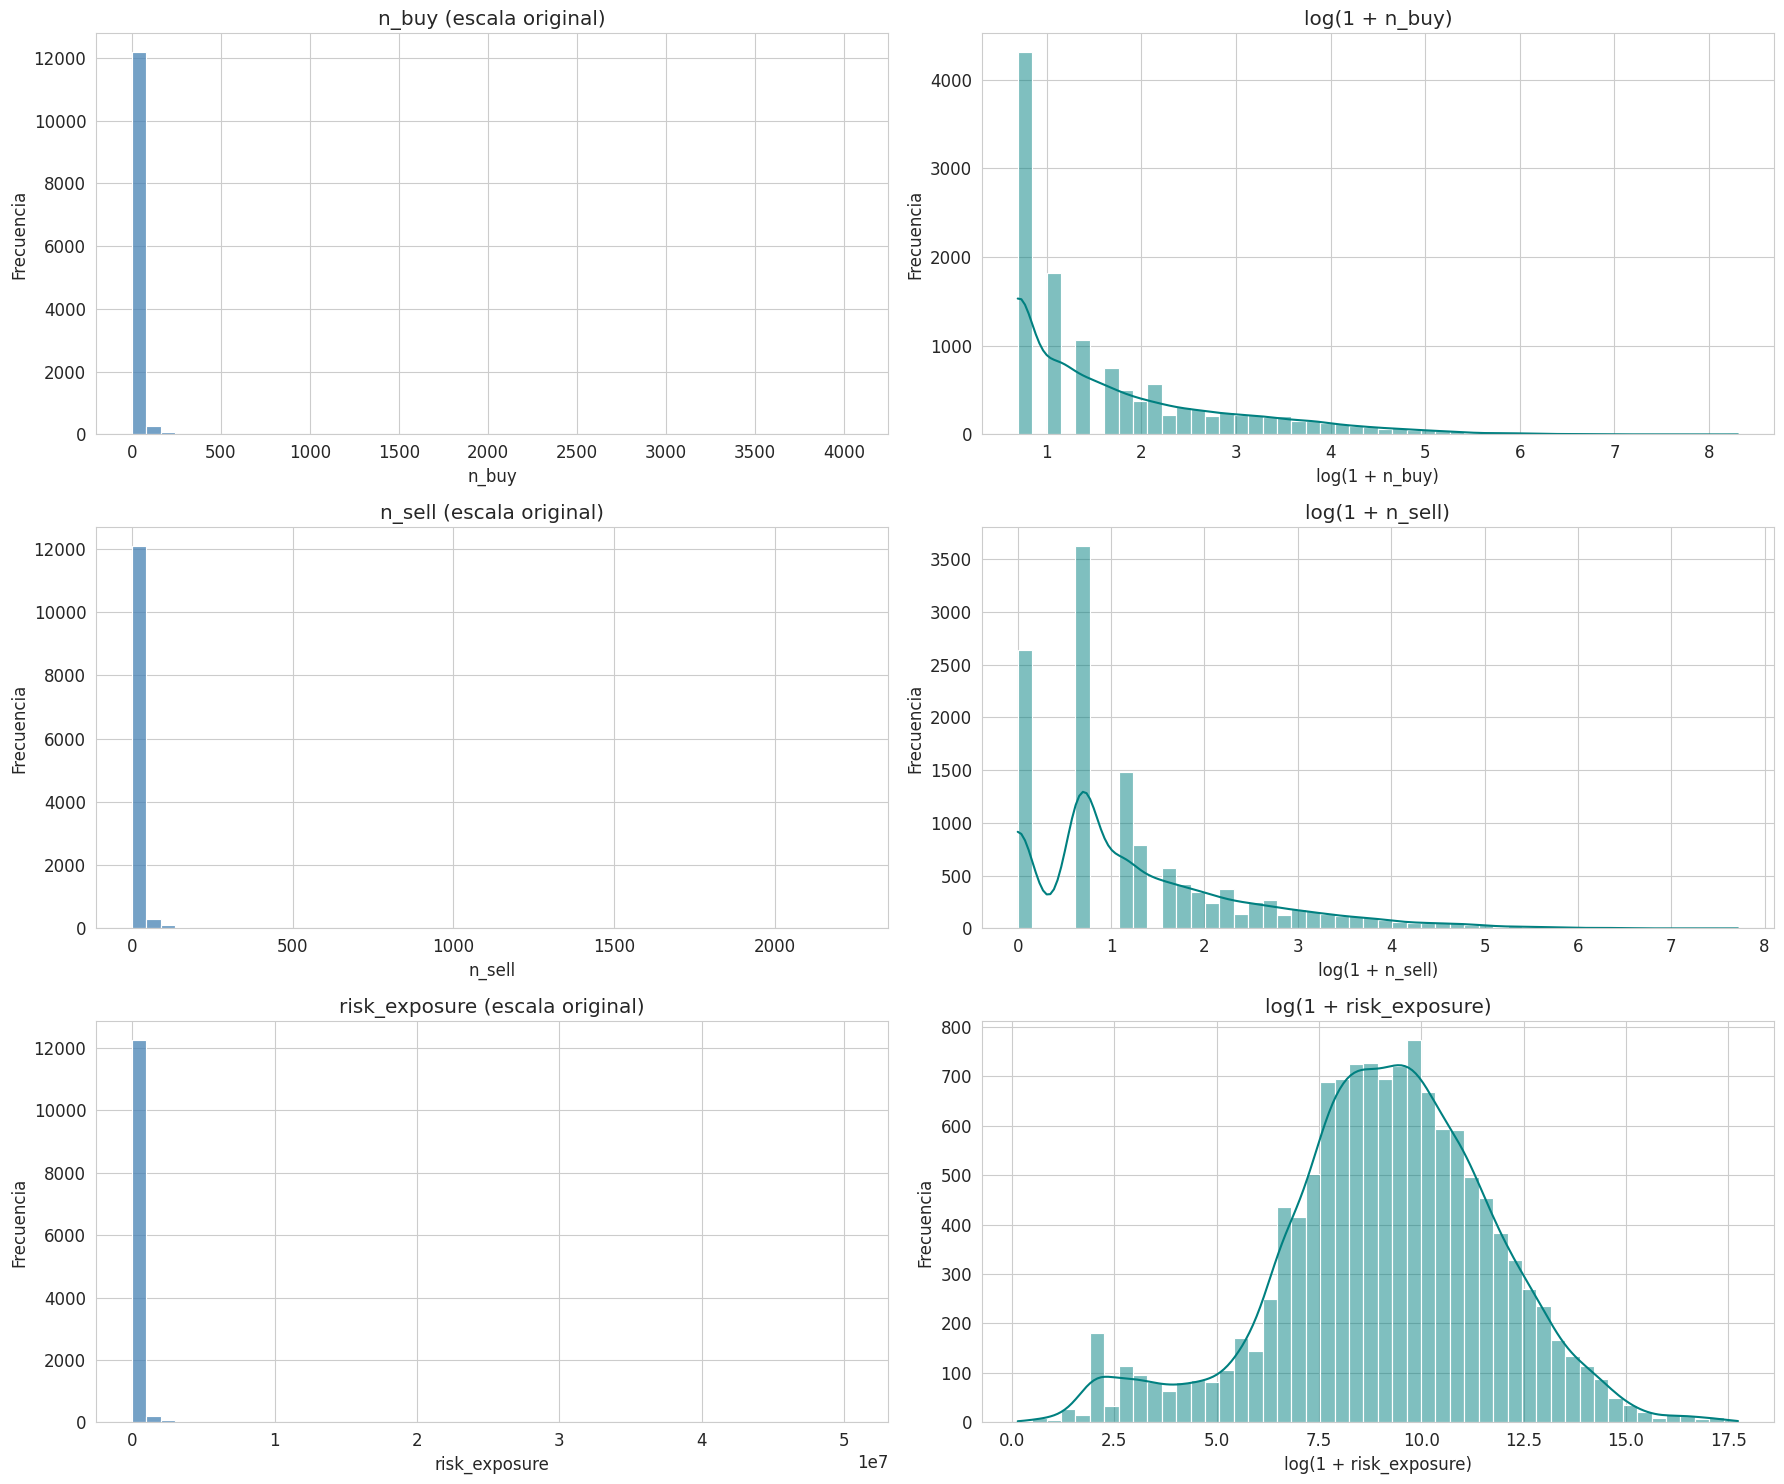

In [ ]:


sns.set_style("whitegrid")
var_skew = ['n_buy', 'n_sell', 'risk_exposure']
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

for i, var in enumerate(var_skew):
    # Histograma en escala original (Columna 0)
    sns.histplot(df_filtrado[var], bins=50, ax=axes[i, 0], color='steelblue', kde=False)
    axes[i, 0].set_title(f'{var} (escala original)')
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Frecuencia')

    # Histograma con transformación log(1+x) (Columna 1)
    sns.histplot(np.log1p(df_filtrado[var]), bins=50, ax=axes[i, 1], color='teal', kde=True)
    axes[i, 1].set_title(f'log(1 + {var})')
    axes[i, 1].set_xlabel(f'log(1 + {var})')
    axes[i, 1].set_ylabel('Frecuencia')

plt.tight_layout()

#plt.savefig("/content/drive/MyDrive/barras_eda.png",
            #dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

Representacion de valores nulos

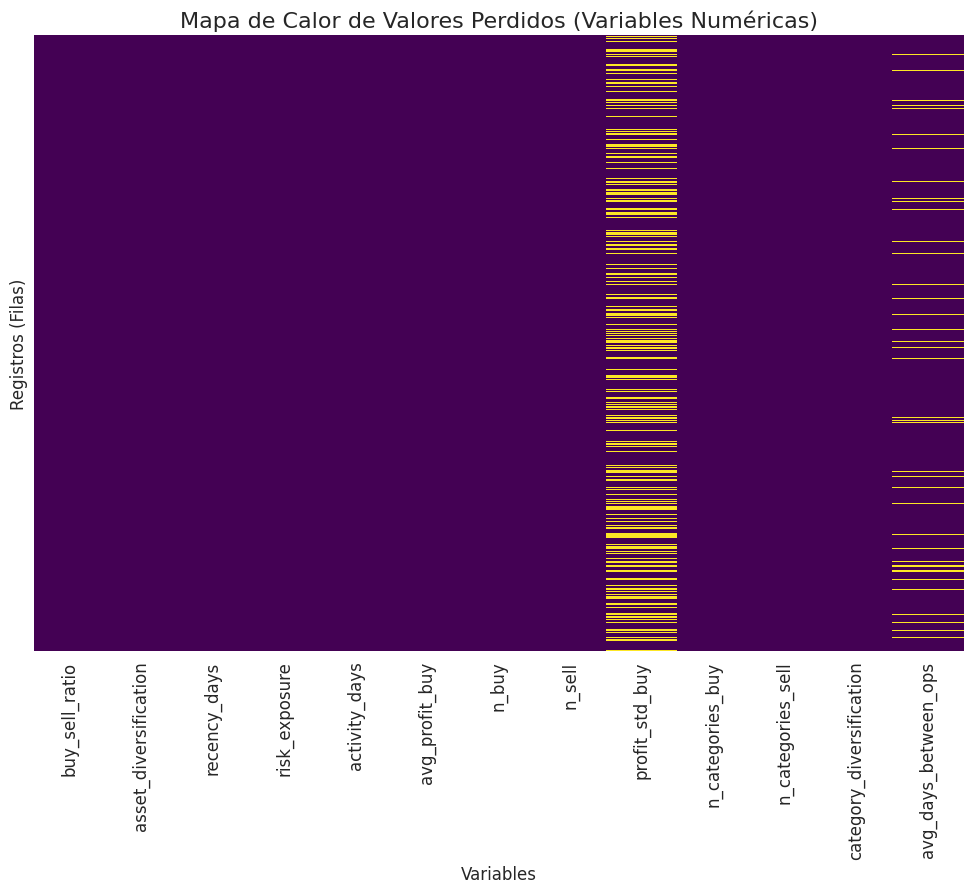

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_filtrado[vars_numericas].isnull(),
            yticklabels=False,
            cbar=False,
            cmap='viridis')


plt.title('Mapa de Calor de Valores Perdidos (Variables Numéricas)', fontsize=16)
plt.xlabel('Variables', fontsize=12)
plt.ylabel('Registros (Filas)', fontsize=12)

#plt.savefig("/content/drive/MyDrive/heatmap_nulos.png",
            #dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

box plot de las variables con mayor asimetria

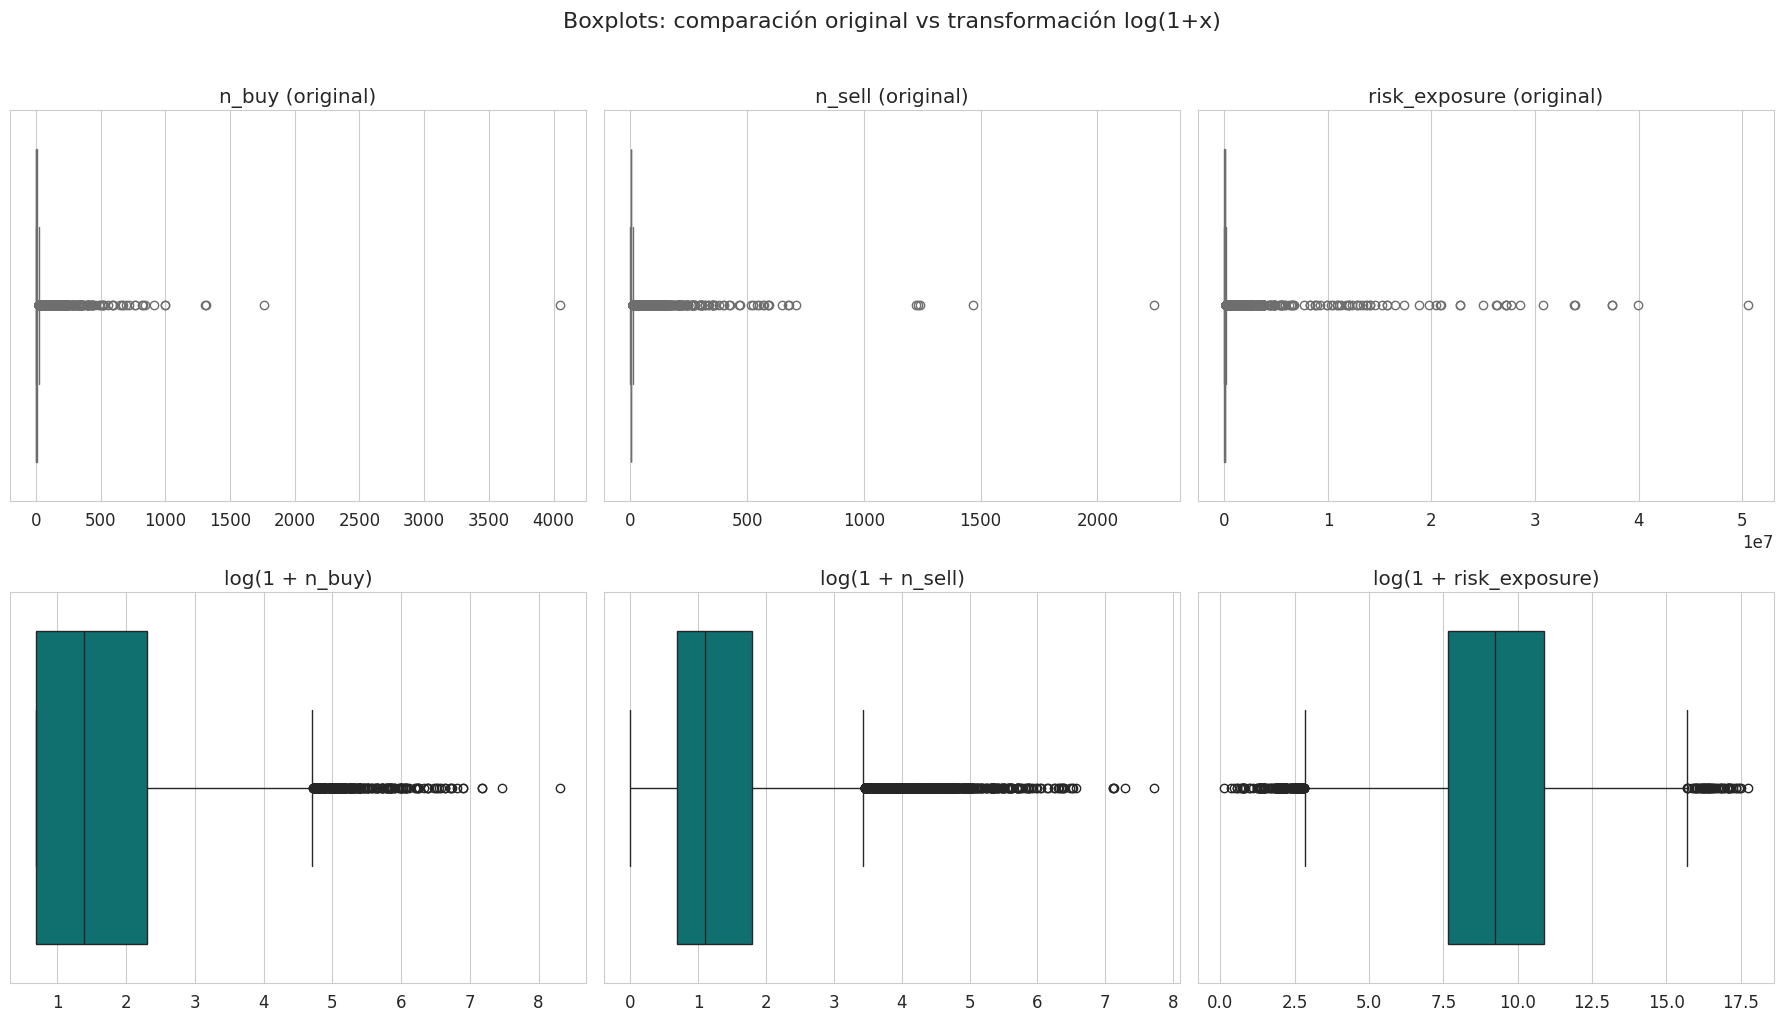

In [ ]:

sns.set_style("whitegrid")
plt.rcParams["font.size"] = 12

var_skew = ['n_buy', 'n_sell', 'risk_exposure']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, var in enumerate(var_skew):
    # (Original)
    sns.boxplot(x=df_filtrado[var], ax=axes[0, i], color='lightcoral')
    axes[0, i].set_title(f'{var} (original)')
    axes[0, i].set_xlabel('')

    #  (Logarítmica)
    sns.boxplot(x=np.log1p(df_filtrado[var]), ax=axes[1, i], color='teal')
    axes[1, i].set_title(f'log(1 + {var})')
    axes[1, i].set_xlabel('')

fig.suptitle('Boxplots: comparación original vs transformación log(1+x)', fontsize=16, y=1.02)
plt.tight_layout()

#plt.savefig("/content/drive/MyDrive/boxplot_comparativa.png",
            #dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Grafico de variables binarias

/tmp/ipykernel_3029/2846663208.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variable', y='Porcentaje_True', data=data_plot, palette='viridis')


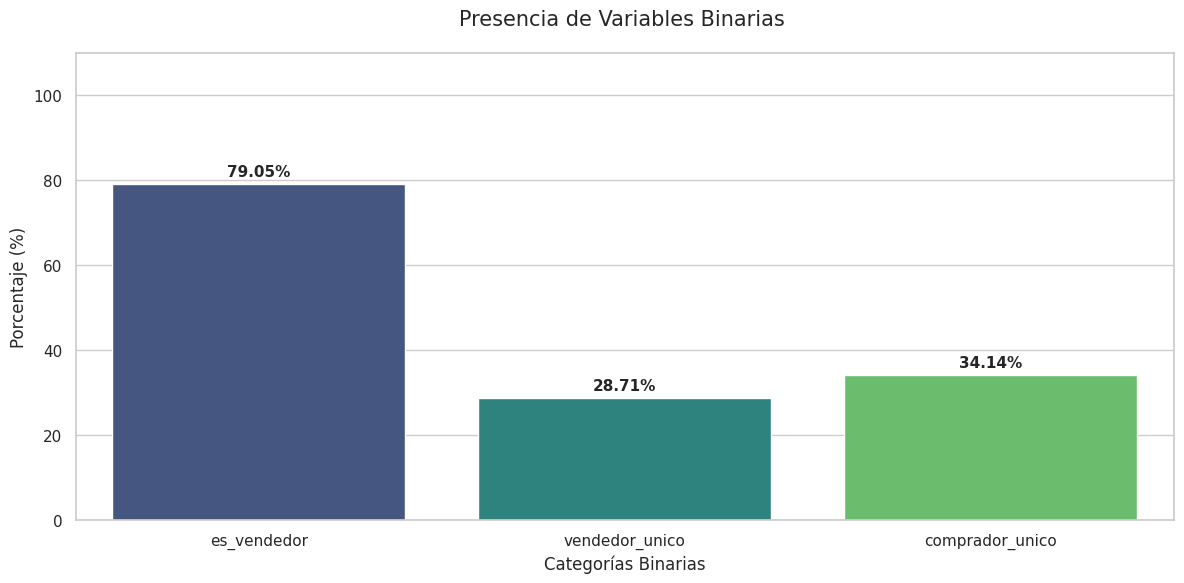

In [ ]:
cols_binarias = ['es_vendedor', 'vendedor_unico', 'comprador_unico']
data_plot = df_filtrado[cols_binarias].mean().mul(100).reset_index()
data_plot.columns = ['Variable', 'Porcentaje_True']
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Variable', y='Porcentaje_True', data=data_plot, palette='viridis')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')
plt.title('Presencia de Variables Binarias ', fontsize=15, pad=20)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Categorías Binarias', fontsize=12)
plt.ylim(0, 110)

plt.tight_layout()

#plt.savefig("/content/drive/MyDrive/barras_dico.png",
           #1 dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Analisis bivariado

Matriz de correlacion

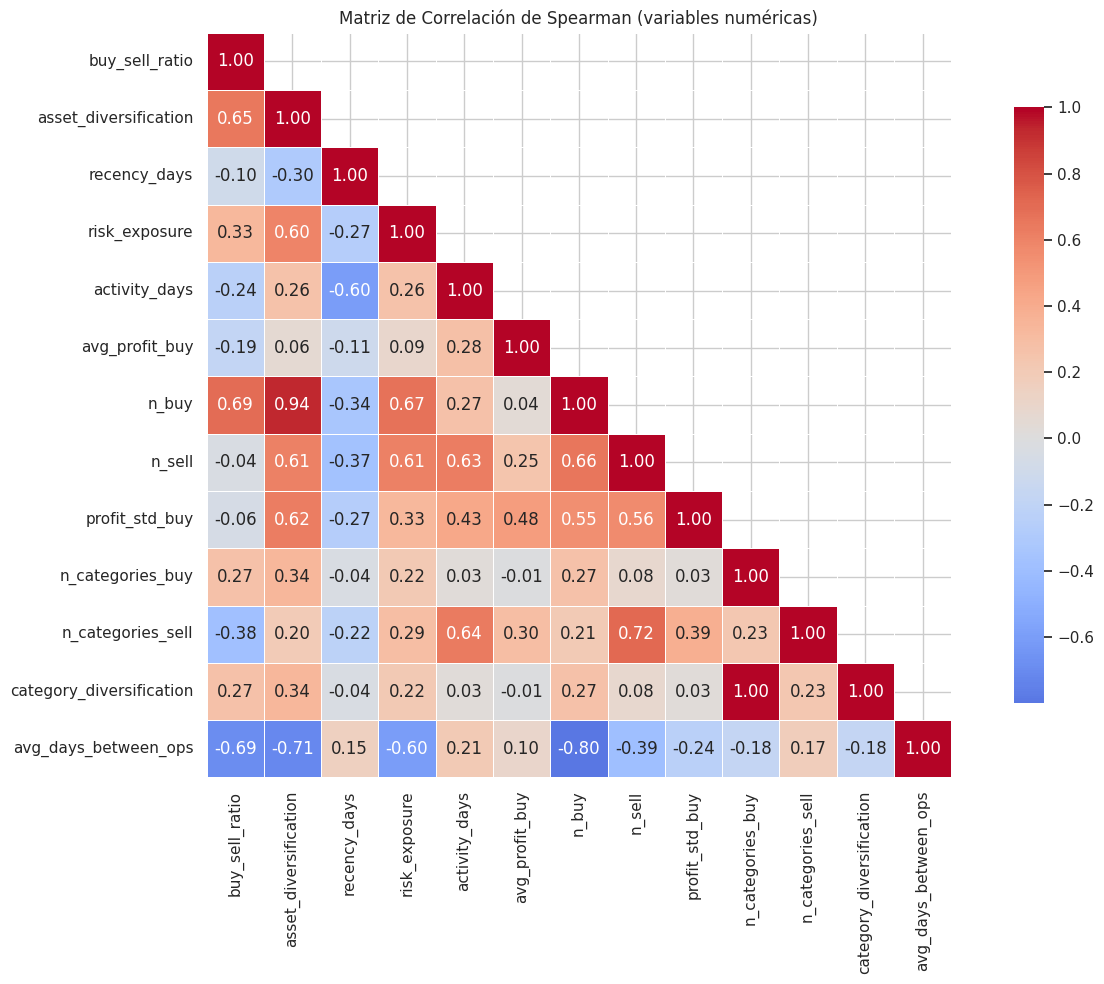

In [ ]:
# Seleccionar variables numéricas
vars_num = [
    'buy_sell_ratio', 'asset_diversification', 'recency_days',
    'risk_exposure', 'activity_days', 'avg_profit_buy',
    'n_buy', 'n_sell', 'profit_std_buy', 'n_categories_buy',
    'n_categories_sell', 'category_diversification', 'avg_days_between_ops'
]

# Calcular matriz de correlación de Spearman
corr_spearman = df_filtrado[vars_num].corr(method='spearman')

# Mapa de calor
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool), k=1)
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Spearman (variables numéricas)')
plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/correlacion_eda.png",
            #dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Scater plots entre variables

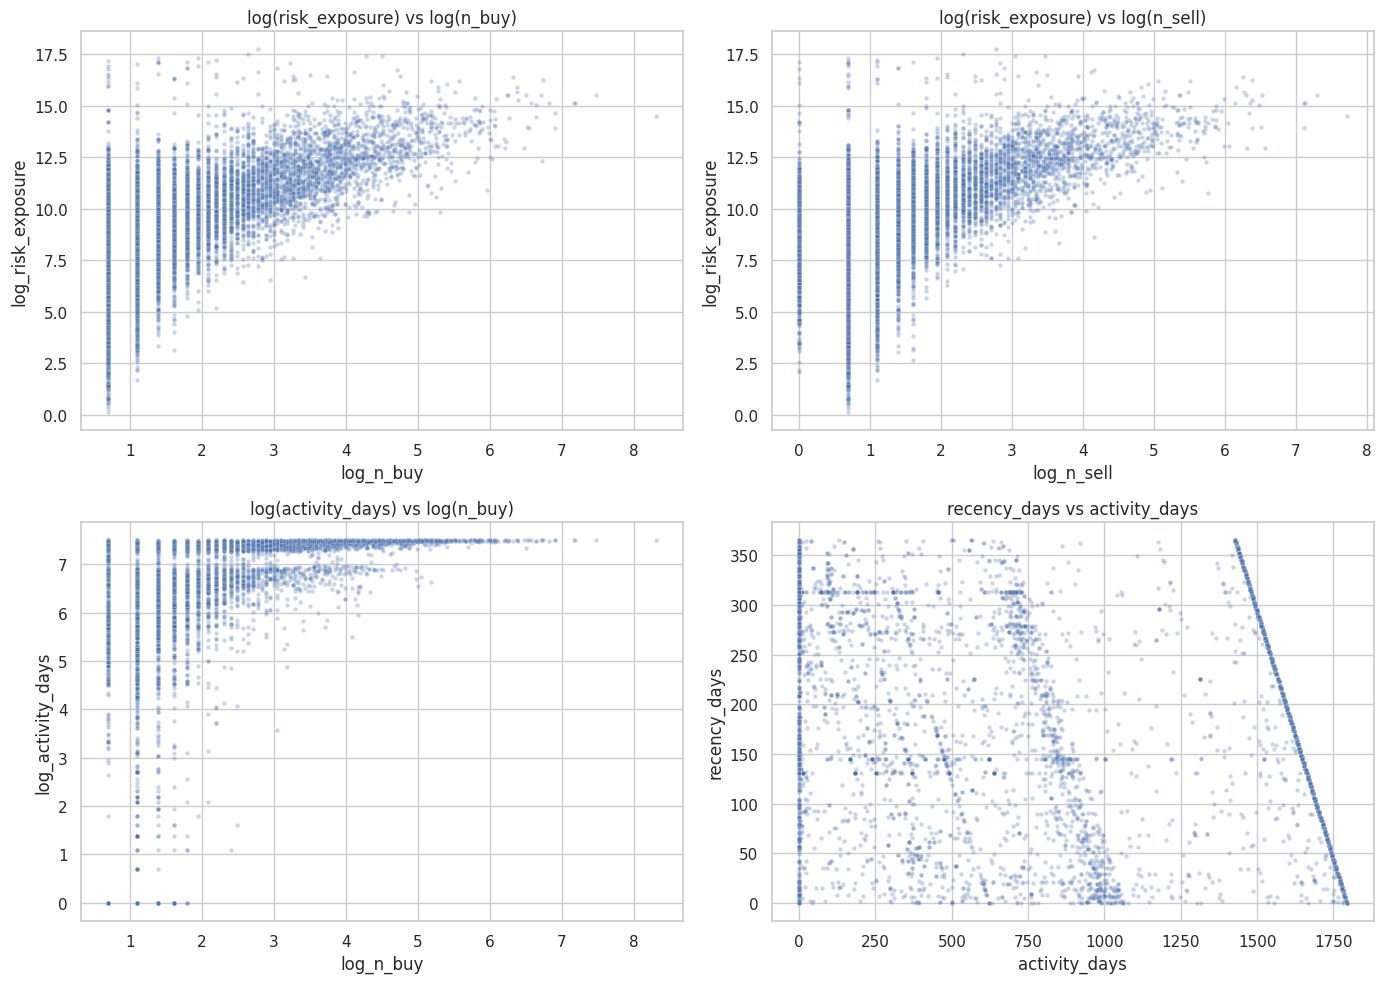

In [ ]:
# Transformacion log(1+x)
df_plot = df_filtrado.copy()
for var in ['risk_exposure', 'n_buy', 'n_sell', 'activity_days']:
    df_plot[f'log_{var}'] = np.log1p(df_plot[var])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# log_risk_exposure vs log_n_buy
sns.scatterplot(data=df_plot, x='log_n_buy', y='log_risk_exposure',
                alpha=0.3, ax=axes[0,0], s=10)
axes[0,0].set_title('log(risk_exposure) vs log(n_buy)')

# log_risk_exposure vs log_n_sell
sns.scatterplot(data=df_plot, x='log_n_sell', y='log_risk_exposure',
                alpha=0.3, ax=axes[0,1], s=10)
axes[0,1].set_title('log(risk_exposure) vs log(n_sell)')

# log_activity_days vs log_n_buy
sns.scatterplot(data=df_plot, x='log_n_buy', y='log_activity_days',
                alpha=0.3, ax=axes[1,0], s=10)
axes[1,0].set_title('log(activity_days) vs log(n_buy)')

# recency_days vs activity_days
sns.scatterplot(data=df_plot, x='activity_days', y='recency_days',
                alpha=0.3, ax=axes[1,1], s=10)
axes[1,1].set_title('recency_days vs activity_days')

plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/scater1_eda.png",
            #dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

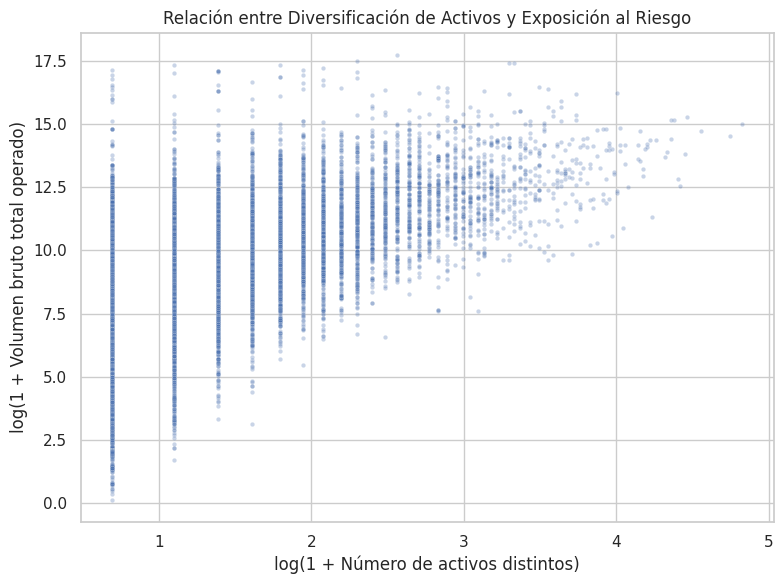

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=np.log1p(df_filtrado['asset_diversification']),
    y=np.log1p(df_filtrado['risk_exposure']),
    alpha=0.3,
    s=10
)
plt.title('Relación entre Diversificación de Activos y Exposición al Riesgo')
plt.xlabel('log(1 + Número de activos distintos)')
plt.ylabel('log(1 + Volumen bruto total operado)')
plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/scater2_eda.png",
           # dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

Graficos de variables categoricas

/tmp/ipykernel_3029/3983658322.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=col, y='percentage', data=counts, ax=axes[i], palette="viridis")
/tmp/ipykernel_3029/3983658322.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=col, y='percentage', data=counts, ax=axes[i], palette="viridis")


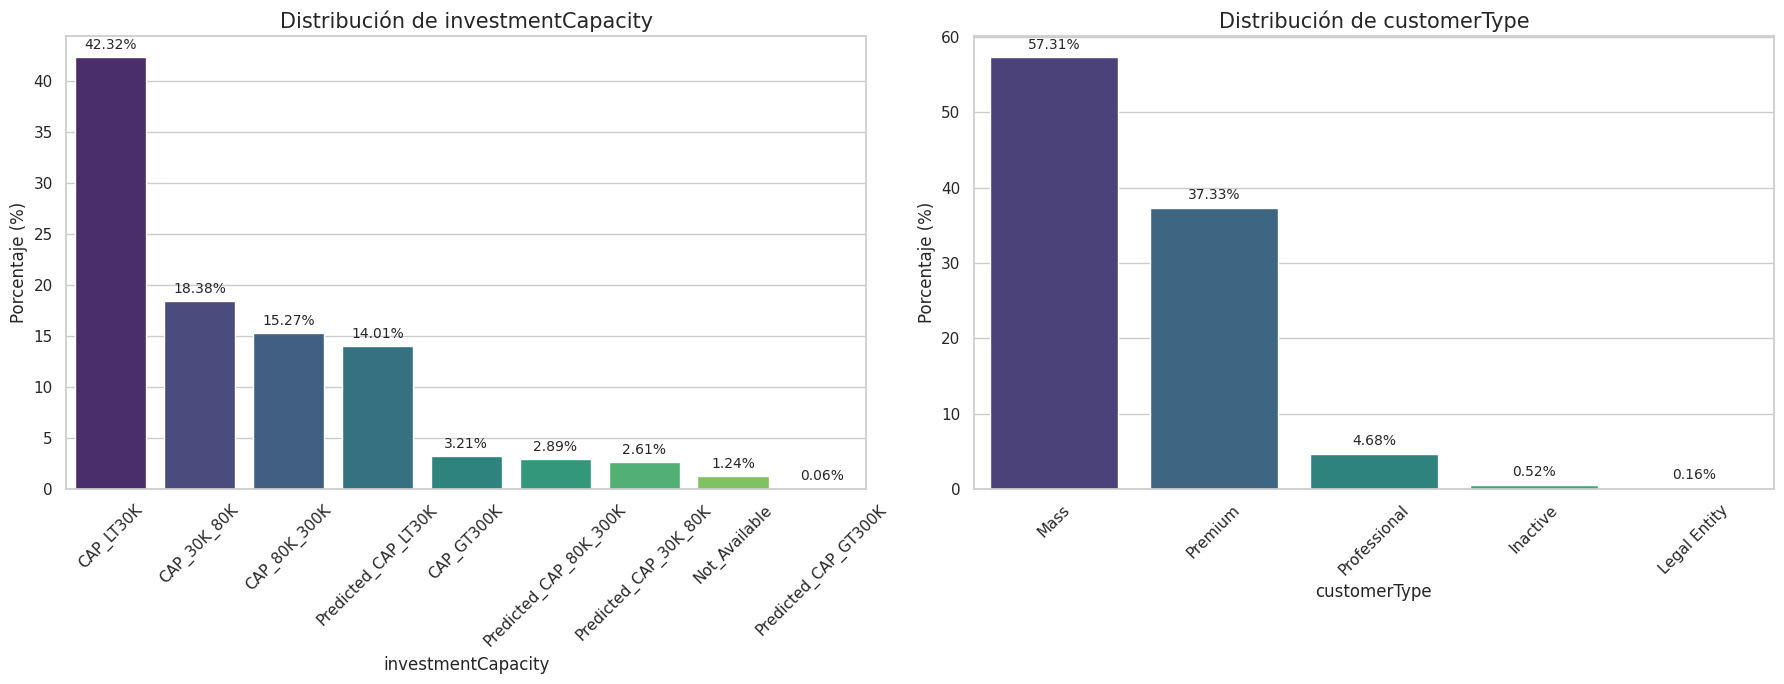

In [ ]:
sns.set_theme(style="whitegrid")
variables = ['investmentCapacity', 'customerType']
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, col in enumerate(variables):
    counts = df_filtrado[col].value_counts(normalize=True).mul(100).round(2).reset_index()
    counts.columns = [col, 'percentage']
    chart = sns.barplot(x=col, y='percentage', data=counts, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Distribución de {col}", fontsize=15)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Porcentaje (%)", fontsize=12)
    if len(counts) > 3:
        axes[i].tick_params(axis='x', rotation=45)
    for p in chart.patches:
        chart.annotate(f'{p.get_height():.2f}%',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points',
                       fontsize=10)
plt.tight_layout()
#plt.savefig("/content/drive/MyDrive/categoricas_unificadas.png",
            #dpi=300, bbox_inches="tight", facecolor="white")

plt.show()